<a href="https://colab.research.google.com/github/kamalahmadov474/Machine_Learning/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install xgboost lightgbm imbalanced-learn streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.1 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import joblib

In [7]:
data = pd.read_csv('/content/creditcard.csv')
print("Dataset shape:", data.shape)
print(data.head())

Dataset shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

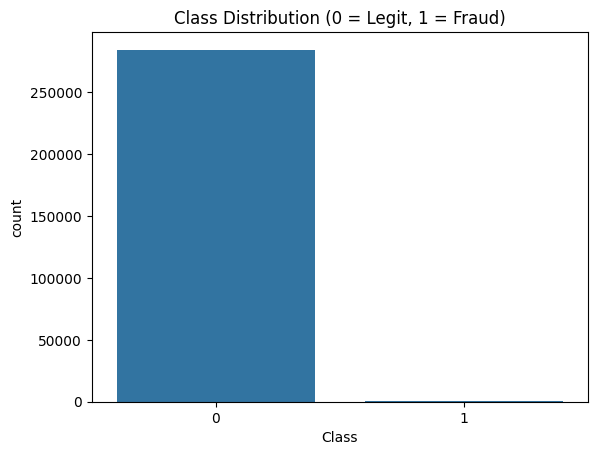

Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
sns.countplot(x='Class', data=data)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.show()
print(data['Class'].value_counts())

In [9]:
X = data.drop('Class', axis=1)
y = data['Class']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Resampled class distribution:\n", pd.Series(y_train_res).value_counts())


Resampled class distribution:
 Class
0    227451
1    227451
Name: count, dtype: int64


In [10]:
clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
clf.fit(X_train_res, y_train_res)

# Predictions
y_pred = clf.predict(X_test)


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [21:20:24] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.61      0.86      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
 [[56810    54]
 [   14    84]]
ROC AUC Score: 0.9784950558726586


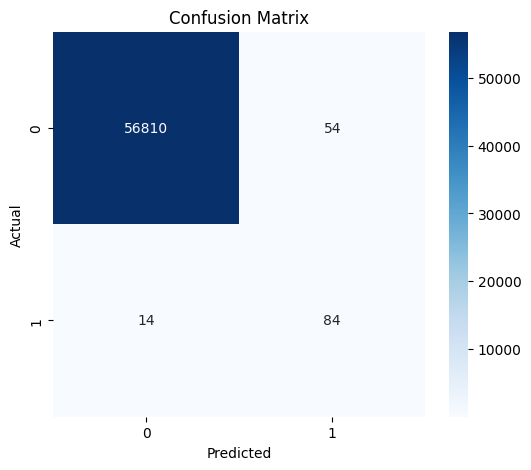

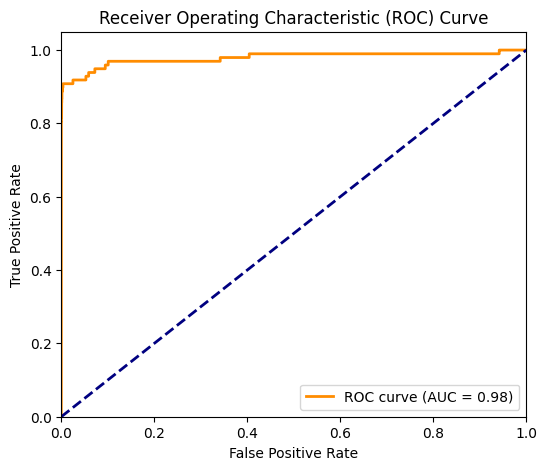

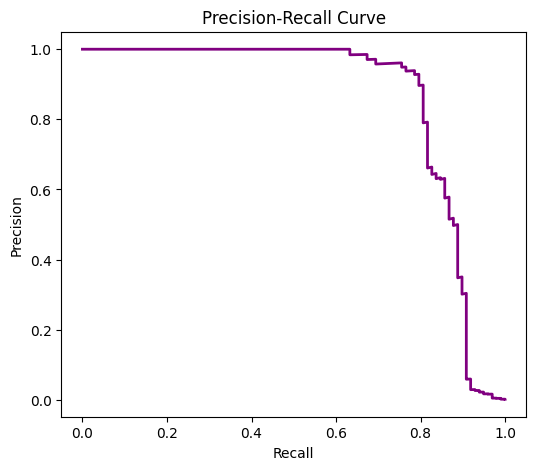

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Print Evaluation Metrics
y_probs = clf.predict_proba(X_test)[:,1]
y_pred = clf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_probs))

# 2️⃣ Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 3️⃣ ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# 4️⃣ Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


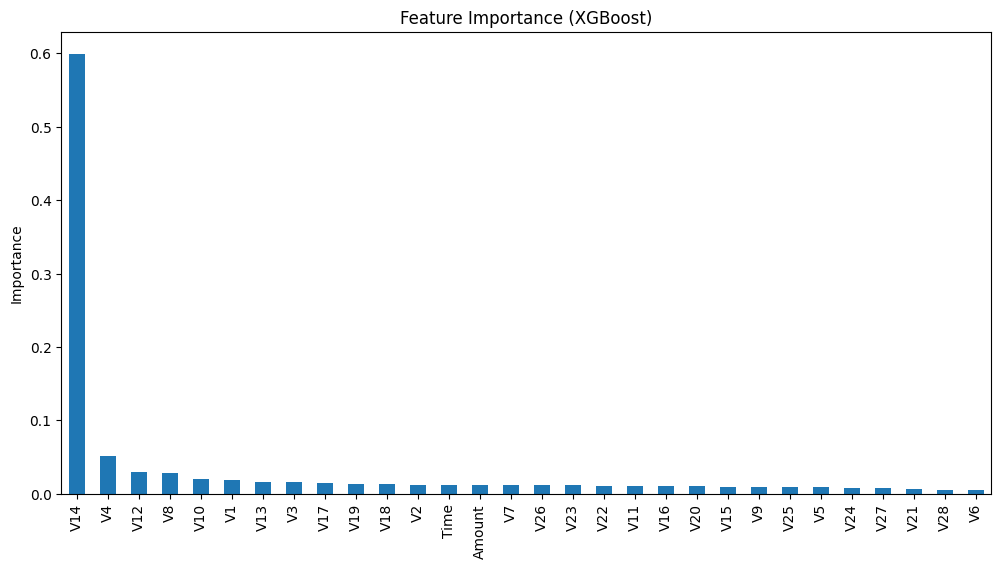

In [12]:
feat_imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(12,6))
feat_imp.plot(kind='bar')
plt.title("Feature Importance (XGBoost)")
plt.ylabel("Importance")
plt.show()

In [13]:
joblib.dump(clf, "clf_xgb.joblib")

['clf_xgb.joblib']

In [14]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

Writing app.py


In [15]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load trained model
model = joblib.load("clf_xgb.joblib")

st.title("Credit Card Fraud Detection Simulator")
st.header("Enter Transaction Details:")

# Input features (adjust to match all dataset columns if needed)
input_data = {}
for col in ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10']:  # extend to all 28 PCA features
    input_data[col] = st.number_input(col, value=0.0)

df_input = pd.DataFrame([input_data])

# Prediction button
if st.button("Predict Fraud"):
    pred = model.predict(df_input)
    prob = model.predict_proba(df_input)[0][1]
    if pred[0] == 1:
        st.error(f"⚠️ Fraud Detected! Probability: {prob:.2f}")
    else:
        st.success(f"✅ Transaction Legitimate. Fraud Probability: {prob:.2f}")


Overwriting app.py
